In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import datasets
from PIL import Image
import os
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder
import zipfile

import torch.nn.functional as F
from rich.console import Console
from rich.progress import Progress, BarColumn, TimeElapsedColumn, TimeRemainingColumn
from rich.table import Table

import pandas as pd
from torch.cuda.amp import autocast, GradScaler


from sklearn.metrics import precision_score, recall_score, f1_score, multilabel_confusion_matrix
import seaborn as sns
import numpy as np

In [2]:
# Install Git in case it's not available in your environment
!apt-get install git

# Clone the repository from GitHub
!git clone https://github.com/Samin1362/MerakiNexus-V2.git

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.15).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
Cloning into 'MerakiNexus-V2'...
remote: Enumerating objects: 6670, done.
remote: Counting objects: 100% (191/191), done.
remote: Compressing objects: 100% (150/150), done.
remote: Total 6670 (delta 67), reused 138 (delta 41), pack-reused 6479 (from 2)
Receiving objects: 100% (6670/6670), 1.94 GiB | 43.41 MiB/s, done.
Resolving deltas: 100% (206/206), done.
Updating files: 100% (6291/6291), done.



Class                    Probability    Weight    Contribution   Note
abstract_expressionism   0.000002       1000.00   0.001633       
surrealism               0.000005       917.40    0.004959       
pop_art                  0.000001       875.80    0.000781       
abstract_art             0.000052       821.60    0.042856       
post_impressionism       0.000012       550.20    0.006672       
cubism                   0.000011       461.90    0.005072       
minimalism               0.000001       405.30    0.000423       
expressionism            0.000005       367.90    0.001659       
chinese_landscape        0.000027       343.90    0.009119       
op_art                   0.000002       189.30    0.000441       
fauvism                  0.000004       168.60    0.000679       
constructivism           0.000001       148.90    0.000089       
art_nouveau              0.000032       139.40    0.004403       
realism                  0.000005       120.70    0.000652       
symbo

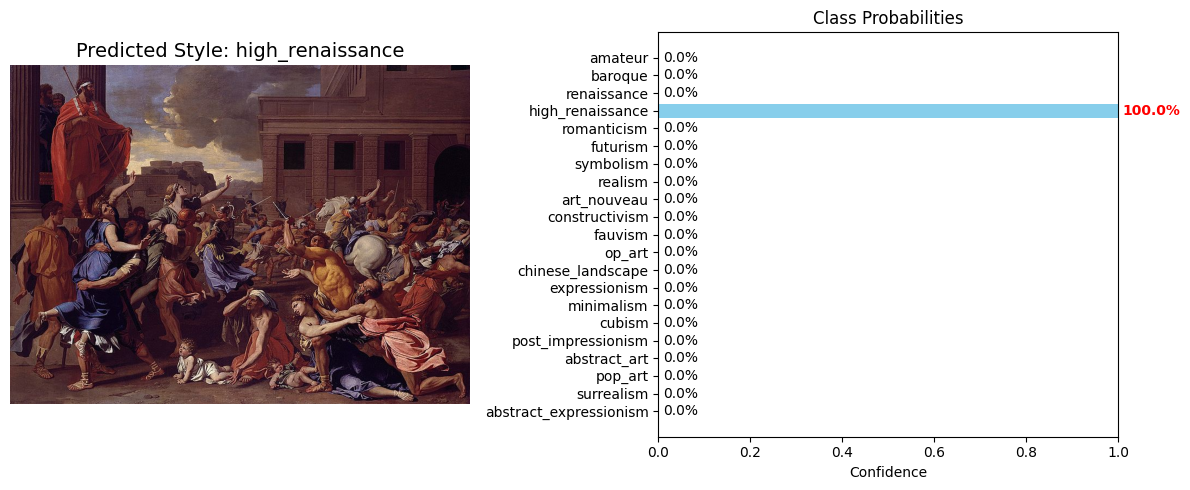

Final Market Value Score: 0.55%


In [20]:
import torch
from torchvision import datasets, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------------
# Load model and configure device
# -------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

scripted_model = torch.jit.load(
    "/content/MerakiNexus-V2/art_classification_model/subject-2/EfficientNet-Base/artwork_classification_model_subject_2_efficientNet.pth"
)
scripted_model.to(device)
scripted_model.eval()

# -------------------------------------------------------------
# Image transforms (224 x 224 for EfficientNet)
# -------------------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# -------------------------------------------------------------
# Custom Dataset class just to extract class names
# -------------------------------------------------------------
class CustomArtworkDataset(datasets.ImageFolder):
    def __getitem__(self, idx):
        path, class_idx = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, class_idx

# Load dataset to obtain class names
dataset_path = "/content/MerakiNexus-V2/art_classification_model/dataset"
train_data = CustomArtworkDataset(root=f"{dataset_path}/train", transform=transform)
class_names = train_data.classes

# -------------------------------------------------------------
# Skewed Weights (amateur → kid_art = 12.8)
# -------------------------------------------------------------
art_style_weights = {
    "abstract_expressionism": 1000.0,
    "surrealism": 917.4,
    "pop_art": 875.8,
    "abstract_art": 821.6,
    "post_impressionism": 550.2,
    "cubism": 461.9,
    "minimalism": 405.3,
    "expressionism": 367.9,
    "chinese_landscape": 343.9,
    "art_nouveau": 139.4,
    "constructivism": 148.9,
    "fauvism": 168.6,
    "op_art": 189.3,
    "realism": 120.7,
    "symbolism": 94.3,
    "futurism": 70.2,
    "romanticism": 56.5,
    "high_renaissance": 37.5,
    "renaissance": 27.7,
    "baroque": 23.6,
    "amateur": 12.8
}

# -------------------------------------------------------------
# Weighted prediction / market value function
# -------------------------------------------------------------
def predict_single_image(image_path, model, transform, class_names):
    # Load & preprocess image
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Predict probabilities
    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.nn.functional.softmax(output, dim=1).cpu().numpy()[0]

    # Prepare weight list and compute contributions
    weighted_data = []
    max_prob_idx = int(np.argmax(probabilities))
    max_prob_class = class_names[max_prob_idx]

    for idx, cls in enumerate(class_names):
        prob = probabilities[idx]
        weight = art_style_weights.get(cls, 0)
        contribution = prob * weight
        is_max_prob = (idx == max_prob_idx)
        weighted_data.append((cls, prob, weight, contribution, is_max_prob))

    # Sort by weight descending
    weighted_data.sort(key=lambda x: x[2], reverse=True)

    # Print contribution table
    print("\n" + "="*75)
    print(f"{'Class':<25}{'Probability':<15}{'Weight':<10}{'Contribution':<15}{'Note'}")
    print("="*75)
    for cls, prob, weight, contrib, is_max in weighted_data:
        note = "<-- Max Probability" if is_max else ""
        line = f"{cls:<25}{prob:<15.6f}{weight:<10.2f}{contrib:<15.6f}{note}"
        if is_max:
            line = "\033[1m" + line + "\033[0m"  # Bold for max probability
        print(line)
    print("="*75)

    # Compute market value
    total_weight = sum([w for _, _, w, _, _ in weighted_data]) or 1
    weighted_sum = sum([c for _, _, _, c, _ in weighted_data])
    market_value_score = (weighted_sum / total_weight) * 100
    print(f"Total Weighted Sum: {weighted_sum:.6f}")
    print(f"Total Weight: {total_weight:.2f}")
    print(f"Market Value Score: {market_value_score:.2f}%")
    print("="*75 + "\n")

    # Visualization
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title(f"Predicted Style: {max_prob_class}", fontsize=14)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    bars = plt.barh([cls for cls, _, _, _, _ in weighted_data],
                    [prob for _, prob, _, _, _ in weighted_data],
                    color='skyblue')
    plt.xlim(0, 1)
    plt.title("Class Probabilities")
    plt.xlabel("Confidence")
    for idx, bar in enumerate(bars):
        if weighted_data[idx][4]:  # max probability
            plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                     f"{bar.get_width()*100:.1f}%", va="center", fontweight="bold", color='red')
        else:
            plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                     f"{bar.get_width()*100:.1f}%", va="center")
    plt.tight_layout()
    plt.show()

    return market_value_score


# -------------------------------------------------------------
# Example usage
# -------------------------------------------------------------
test_image_path = "4.jpg"
score = predict_single_image(test_image_path, scripted_model, transform, class_names)
print(f"Final Market Value Score: {score:.2f}%")
